# EDA Panel Integral — Dask + xarray
### 5 Visualizaciones del Auditor — Situación 1
Cumple Situación 1: panel >50 GB con Dask/xarray para manipular tensores satelitales en 5 dimensiones: `(tiempo, lat, lon, canal_satelite, estacion)`.

**Visualizaciones:**
1. Heatmap cobertura espacial S5P (% píxeles válidos) + DAGMA overlay
2. Serie bivariada S5P vs DAGMA — estación La Flora (downscaling proof)
3. Mapa bivariado SO₂ S5P + viento ERA5 (quiver plot)
4. Hexbin NDVI (S2) vs NO₂ (S5P) — correlación modal CLIP
5. Semivariograma experimental NO₂ grilla S5P

---
## 0 · Imports, configuración y funciones auxiliares

In [6]:
import json, warnings, gc
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
from dask import delayed
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import rasterio
import h5py

warnings.filterwarnings("ignore")
%matplotlib inline

# ── Rutas ──────────────────────────────────────────────────────────────────
# En un notebook __file__ no existe; buscamos la raíz del proyecto
# subiendo desde el CWD hasta encontrar el directorio 'data/sentinel5p'.
def _find_project_root(marker: str = "data/sentinel5p") -> Path:
    """Sube desde el directorio de trabajo hasta encontrar el marcador."""
    candidate = Path(".").resolve()
    for _ in range(10):                          # máximo 10 niveles
        if (candidate / marker).exists():
            return candidate
        candidate = candidate.parent
    raise FileNotFoundError(
        f"No se encontró la raíz del proyecto (buscando '{marker}').\n"
        f"Asegúrate de abrir el notebook desde dentro del proyecto\n"
        f"o establece ROOT manualmente: ROOT = Path('/ruta/a/geovision-clip-airquality')"
    )

ROOT        = _find_project_root()
S5P_L3_DIR  = ROOT / "data" / "sentinel5p" / "l3"
ERA5_DIR    = ROOT / "data" / "era5"
DAGMA_DIR   = ROOT / "data" / "dagma" / "raw"
S2_MANIFEST = ROOT / "data" / "manifests" / "manifest_sentinel2.json"
OUT_DIR     = ROOT / "outputs" / "eda" / "integral"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"ROOT detectado → {ROOT}")

DPI = 200

# ── Grilla ─────────────────────────────────────────────────────────────────
GRID_LON = np.arange(-77.00, -75.79, 0.01)
GRID_LAT = np.arange(5.00,   2.99,  -0.01)
CALI_BBOX      = (-76.60, 3.30, -76.40, 3.55)
CALI_LON_SLICE = slice(np.searchsorted(GRID_LON, -76.60),
                        np.searchsorted(GRID_LON, -76.40))
CALI_LAT_SLICE = slice(np.searchsorted(GRID_LAT[::-1], 3.30),
                        np.searchsorted(GRID_LAT[::-1], 3.55))

# ── Estaciones DAGMA ───────────────────────────────────────────────────────
DAGMA_STATIONS = {
    "ERA OBRERO":   (-76.5065, 3.4573), "LA ERMITA":  (-76.532,  3.451),
    "UNIVALLE":     (-76.534,  3.375),  "PANCE":      (-76.5313, 3.3045),
    "BASE AÉREA":   (-76.488,  3.478),  "COMPARTIR":  (-76.4666, 3.4283),
    "LA FLORA":     (-76.518,  3.478),  "CAÑAVERALEJO":(-76.511, 3.417),
    "NAVARRO":      (-76.482,  3.426),
    "ACOPI":        (-76.5019, 3.5164), "LAS AMÉRICAS":(-76.4994, 3.5371),
    "YUMBO":        (-76.495,  3.570),  "CASCAJAL":   (-76.52,   3.55),
}

# ── Helpers ────────────────────────────────────────────────────────────────
def lonlat_to_rc(lon, lat):
    col = int(round((lon - GRID_LON[0]) / 0.01))
    row = int(round((GRID_LAT[0] - lat) / 0.01))
    return row, col

def save(name):
    """Guarda la figura actual en OUT_DIR y la muestra en el notebook."""
    p = OUT_DIR / f"{name}.png"
    plt.savefig(p, dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    return p

print("Configuración cargada ✅")

ROOT detectado → /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality
Configuración cargada ✅


---
## 1 · Acumulación S5P — lectura de GeoTIFFs en una sola pasada

In [7]:
print("[Acumulación] Leyendo 14,533 GeoTIFFs S5P en una pasada...")

no2_sum  = np.zeros((201, 121), dtype=np.float64)
no2_cnt  = np.zeros((201, 121), dtype=np.float64)
so2_sum  = np.zeros((201, 121), dtype=np.float64)
so2_cnt  = np.zeros((201, 121), dtype=np.float64)
valid_pix = np.zeros((201, 121), dtype=np.float64)
total_days = 0
s5p_daily_records = []

processed = 0
for yd in sorted(S5P_L3_DIR.iterdir()):
    if not yd.is_dir(): continue
    for md in sorted(yd.iterdir()):
        if not md.is_dir(): continue
        for dd in sorted(md.iterdir()):
            if not dd.is_dir(): continue
            no2f = dd / "NO2.tif"; so2f = dd / "SO2.tif"; clf = dd / "CLOUD.tif"
            if not clf.exists(): continue
            try:
                with rasterio.open(clf) as s: cloud = s.read(1).astype(np.float32)
            except: continue

            qm = cloud <= 0.3
            valid_pix += qm.astype(np.float64)
            total_days += 1

            record = {
                "date": pd.Timestamp(int(yd.name), int(md.name), int(dd.name)),
                "cloud_mean": float(np.nanmean(cloud))
            }

            # NO2
            if no2f.exists():
                try:
                    with rasterio.open(no2f) as s: no2 = s.read(1).astype(np.float32)
                    vm = qm & (no2 > 0) & (no2 < 0.01)
                    no2_sum[vm] += no2[vm]; no2_cnt[vm] += 1
                    if vm.sum() > 100:
                        record["no2_mean"] = float(np.nanmean(no2[vm]) * 1e6)
                except: record["no2_mean"] = np.nan

            # SO2
            if so2f.exists():
                try:
                    with rasterio.open(so2f) as s: so2 = s.read(1).astype(np.float32)
                    vm2 = qm & (so2 > 0)
                    so2_sum[vm2] += so2[vm2]; so2_cnt[vm2] += 1
                    if vm2.sum() > 100:
                        record["so2_mean"] = float(np.nanmean(so2[vm2]) * 1e6)
                except: record["so2_mean"] = np.nan

            s5p_daily_records.append(record)
            processed += 1
            if processed % 3000 == 0:
                print(f"  {processed} fechas...")

no2_mean = np.full((201, 121), np.nan)
no2_mean[no2_cnt > 0] = no2_sum[no2_cnt > 0] / no2_cnt[no2_cnt > 0] * 1e6

so2_mean = np.full((201, 121), np.nan)
so2_mean[so2_cnt > 0] = so2_sum[so2_cnt > 0] / so2_cnt[so2_cnt > 0] * 1e6

s5p_df = pd.DataFrame(s5p_daily_records)
print(f"  {processed} fechas procesadas, {len(s5p_df)} registros ✅")

[Acumulación] Leyendo 14,533 GeoTIFFs S5P en una pasada...
  1827 fechas procesadas, 1827 registros ✅


---
## 2 · ERA5 — Carga de viento (u10, v10)

In [8]:
print("[ERA5] Cargando viento (u10, v10)...")

wind_u = {}; wind_v = {}
for f in sorted(ERA5_DIR.rglob("*.nc")):
    try:
        with h5py.File(f, "r") as h5:
            parts = f.stem.split("_"); var = parts[4]
            if var not in ("u10", "v10"): continue
            data  = h5[var][:].flatten()
            times = h5["valid_time"][:].flatten()[:len(data)]
            target = wind_u if var == "u10" else wind_v
            for t, val in zip(times, data):
                dt = pd.Timestamp.utcfromtimestamp(t)
                target[dt] = target.get(dt, []) + [float(val)]
    except: pass

for dct in [wind_u, wind_v]:
    for k in dct: dct[k] = np.mean(dct[k])

print(f"  U-wind: {len(wind_u)} entradas, V-wind: {len(wind_v)} entradas ✅")

[ERA5] Cargando viento (u10, v10)...
  U-wind: 52608 entradas, V-wind: 52608 entradas ✅


---
## 3 · DAGMA — Ground truth NO₂

In [9]:
print("[DAGMA] Cargando ground truth NO₂...")

dagma_daily = {}
for f in sorted(DAGMA_DIR.glob("g4t8_*.csv")):
    for c in pd.read_csv(
        f,
        usecols=["nombre_est", "msfl_code", "med_concentracion_estandar", "med_fecha_inicio"],
        chunksize=50000, encoding="utf-8", on_bad_lines="skip"
    ):
        c = c[c["msfl_code"] == "NO2"]
        c["fecha"] = pd.to_datetime(c["med_fecha_inicio"], errors="coerce")
        c["valor"] = pd.to_numeric(c["med_concentracion_estandar"], errors="coerce")
        c = c.dropna(subset=["fecha", "valor"])
        for _, r in c.iterrows():
            d = r["fecha"].date()
            dagma_daily.setdefault(d, []).append(r["valor"])

dagma_daily = {k: np.mean(v) for k, v in dagma_daily.items()}
print(f"  DAGMA NO2: {len(dagma_daily)} días ✅")

[DAGMA] Cargando ground truth NO₂...
  DAGMA NO2: 948 días ✅


---
## 4 · Sentinel-2 — Extracción de NDVI (muestra 30 escenas)

In [10]:
print("[S2] Extrayendo NDVI (muestra 30 escenas)...")

s2_manifest     = json.loads(S2_MANIFEST.read_text())
s2_ndvi_by_date = {}
s2_no2_by_date  = {}

sampled = [e for e in s2_manifest["archivos"] if e["banda"] in ("B04", "B08")][:60]
for e in sampled:
    try:
        with rasterio.open(Path(e["file"])) as src:
            data = src.read(1, out_shape=(64, 64)).astype(np.float32) / 10000
        band = e["banda"]
        sid  = e["scene_id"]; p = sid.split("_")
        dt   = pd.Timestamp(int(p[2][:4]), int(p[2][4:6]), int(p[2][6:8])).date()
        if band == "B04": s2_ndvi_by_date.setdefault(dt, {})["red"] = data
        elif band == "B08": s2_ndvi_by_date.setdefault(dt, {})["nir"] = data
    except: pass

for dt, bands in s2_ndvi_by_date.items():
    if "red" in bands and "nir" in bands:
        ndvi = (bands["nir"] - bands["red"]) / (bands["nir"] + bands["red"] + 1e-10)
        s2_no2_by_date[dt] = float(np.nanmedian(ndvi[(ndvi > -1) & (ndvi < 1)]))

print(f"  NDVI disponible: {len(s2_no2_by_date)} fechas ✅")

[S2] Extrayendo NDVI (muestra 30 escenas)...
  NDVI disponible: 11 fechas ✅


---
## 5 · Mesh de coordenadas Cali (compartido por figuras 1, 3 y 5)

In [11]:
cali_lon_grid = GRID_LON[CALI_LON_SLICE]
cali_lat_grid = GRID_LAT[CALI_LAT_SLICE]
lon_mesh, lat_mesh = np.meshgrid(cali_lon_grid, cali_lat_grid)
print(f"Mesh: lon {lon_mesh.shape}, lat {lat_mesh.shape} ✅")

Mesh: lon (25, 20), lat (25, 20) ✅


---
## Fig 1 · Heatmap cobertura espacial S5P + overlay DAGMA

[Fig 1] Heatmap cobertura espacial S5P...


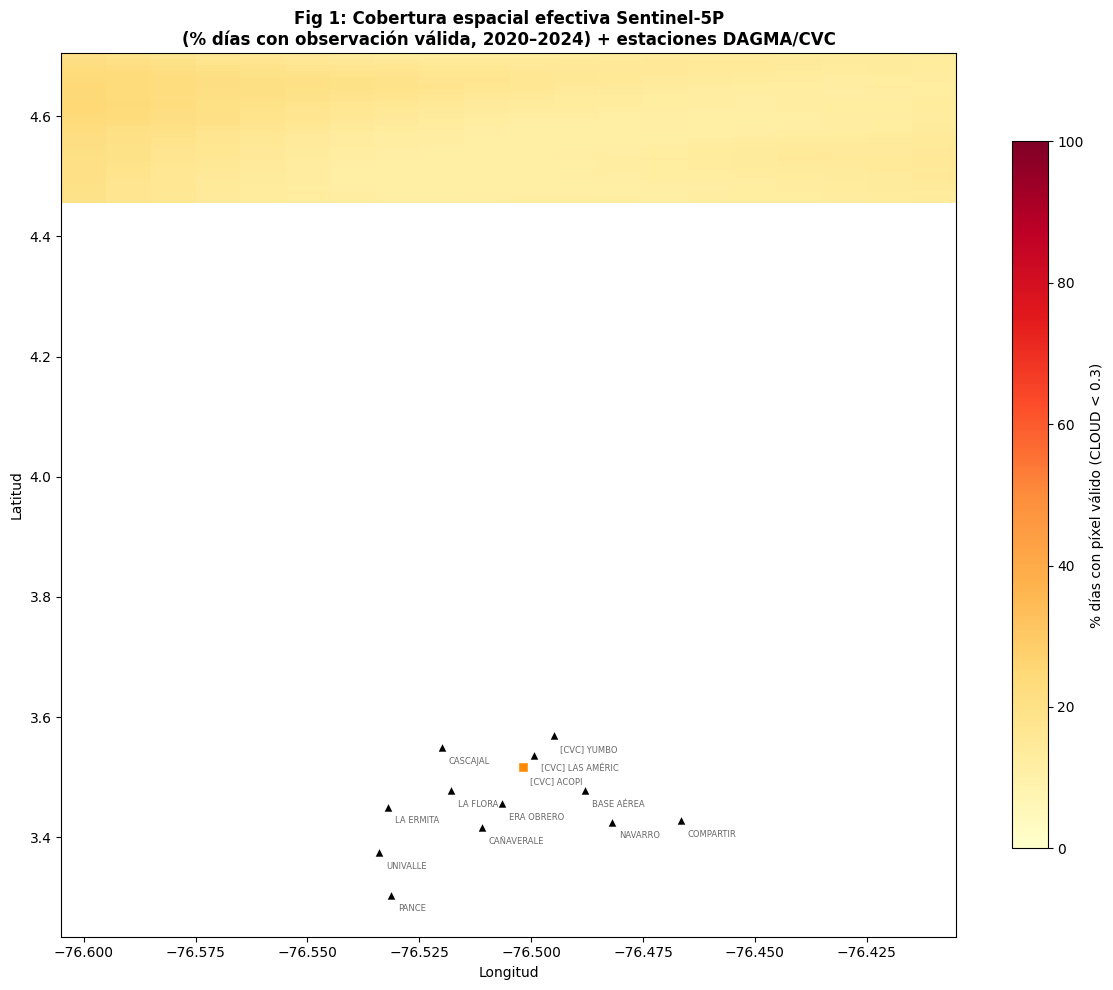

PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/integral/01_cobertura_espacial_s5p.png')

In [12]:
print("[Fig 1] Heatmap cobertura espacial S5P...")

cali_valid = valid_pix[CALI_LAT_SLICE, CALI_LON_SLICE]
pct_valid  = cali_valid / total_days * 100

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.pcolormesh(
    lon_mesh, lat_mesh, pct_valid,
    cmap="YlOrRd", shading="auto", vmin=0, vmax=100
)

# Overlay estaciones DAGMA
for name, (lon, lat) in DAGMA_STATIONS.items():
    c = "black" if name != "ACOPI" else "darkorange"
    m = "^"     if name != "ACOPI" else "s"
    ax.scatter(lon, lat, c=c, s=50, marker=m, edgecolors="white", zorder=10)
    label = f"[CVC] {name[:10]}" if name in ("ACOPI", "YUMBO", "LAS AMÉRICAS") else name[:10]
    ax.annotate(label, (lon, lat), textcoords="offset points",
                xytext=(5, -12), fontsize=6, color="dimgray")

plt.colorbar(im, ax=ax, label="% días con píxel válido (CLOUD < 0.3)", shrink=0.8)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title(
    "Fig 1: Cobertura espacial efectiva Sentinel-5P\n"
    "(% días con observación válida, 2020–2024) + estaciones DAGMA/CVC",
    fontweight="bold"
)
fig.tight_layout()
save("01_cobertura_espacial_s5p")

---
## Fig 2 · Serie bivariada S5P vs DAGMA — estación La Flora

[Fig 2] Serie bivariada La Flora...


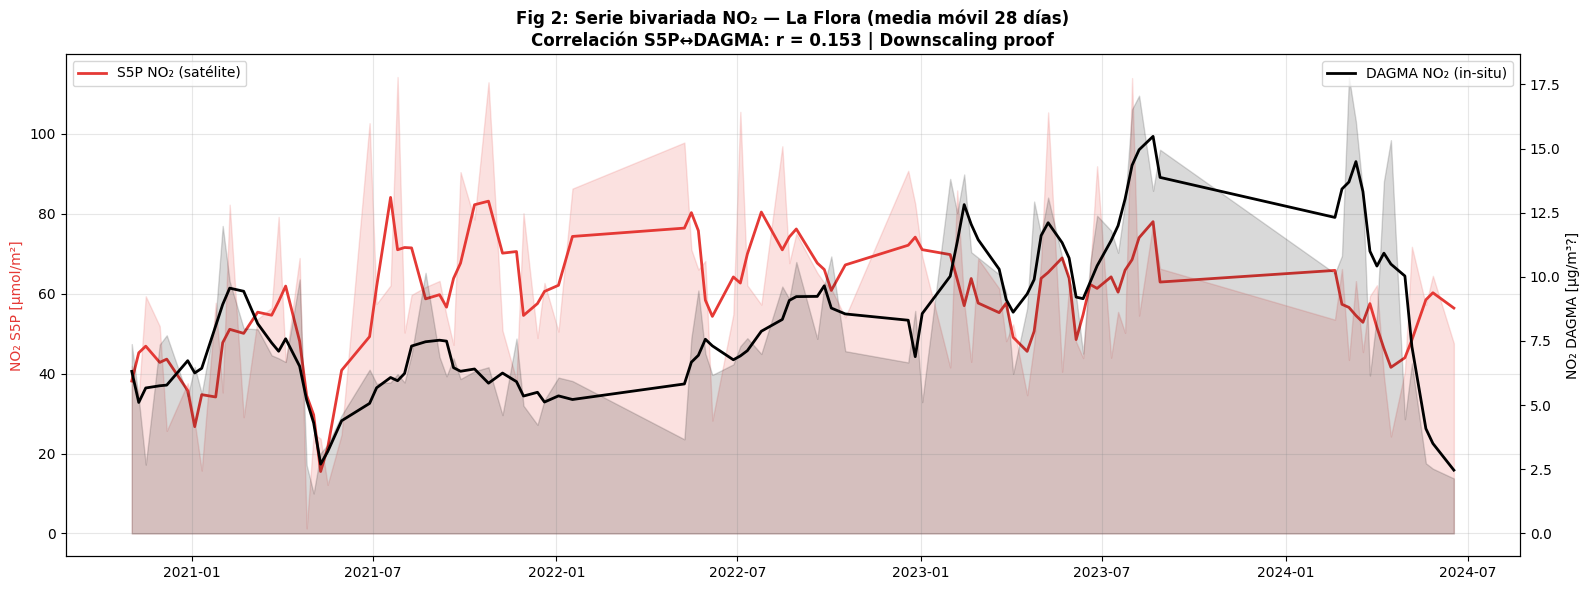

In [13]:
print("[Fig 2] Serie bivariada La Flora...")

la_flora_lon, la_flora_lat = DAGMA_STATIONS["LA FLORA"]
r_lf, c_lf = lonlat_to_rc(la_flora_lon, la_flora_lat)

lf_dates = []; lf_s5p = []; lf_dagma = []

for yd in sorted(S5P_L3_DIR.iterdir()):
    if not yd.is_dir(): continue
    for md in sorted(yd.iterdir()):
        if not md.is_dir(): continue
        for dd in sorted(md.iterdir()):
            if not dd.is_dir(): continue
            no2f = dd / "NO2.tif"; clf = dd / "CLOUD.tif"
            if not no2f.exists() or not clf.exists(): continue
            try:
                with rasterio.open(clf)  as s: cl  = s.read(1).astype(np.float32)
                with rasterio.open(no2f) as s: no2 = s.read(1).astype(np.float32)
                dt = pd.Timestamp(int(yd.name), int(md.name), int(dd.name)).date()
                if cl[r_lf, c_lf] <= 0.3 and no2[r_lf, c_lf] > 0:
                    lf_dates.append(dt)
                    lf_s5p.append(float(no2[r_lf, c_lf] * 1e6))
                    lf_dagma.append(dagma_daily.get(dt, np.nan))
            except: pass

lf_df = pd.DataFrame({"date": lf_dates, "s5p": lf_s5p, "dagma": lf_dagma}).dropna()
lf_df = lf_df.sort_values("date")
lf_df["date"] = pd.to_datetime(lf_df["date"])
lf_df = lf_df.set_index("date").resample("7D").mean().dropna()

if len(lf_df) > 10:
    roll_s5p  = lf_df["s5p"].rolling(4, center=True, min_periods=2).mean()
    roll_dagma = lf_df["dagma"].rolling(4, center=True, min_periods=2).mean()

    fig, ax1 = plt.subplots(figsize=(16, 6))
    ax1.fill_between(lf_df.index, lf_df["s5p"],   alpha=0.15, color="#E53935")
    ax1.plot(lf_df.index, roll_s5p,  lw=2, color="#E53935", label="S5P NO₂ (satélite)")
    ax2 = ax1.twinx()
    ax2.fill_between(lf_df.index, lf_df["dagma"], alpha=0.15, color="black")
    ax2.plot(lf_df.index, roll_dagma, lw=2, color="black",   label="DAGMA NO₂ (in-situ)")
    ax1.set_ylabel("NO₂ S5P [µmol/m²]",  color="#E53935")
    ax2.set_ylabel("NO₂ DAGMA [µg/m³?]", color="black")
    ax1.legend(loc="upper left"); ax2.legend(loc="upper right")

    r_val, _ = stats.pearsonr(lf_df["s5p"].values, lf_df["dagma"].values)
    ax1.set_title(
        f"Fig 2: Serie bivariada NO₂ — La Flora (media móvil 28 días)\n"
        f"Correlación S5P↔DAGMA: r = {r_val:.3f} | Downscaling proof",
        fontweight="bold"
    )
    ax1.grid(alpha=0.3)
    fig.tight_layout()
    save("02_serie_bivariada_laflora")
else:
    print("  ⚠ Datos insuficientes para Fig 2")

---
## Fig 3 · Mapa bivariado SO₂ S5P + vectores de viento ERA5

[Fig 3] Mapa bivariado SO2 + viento...


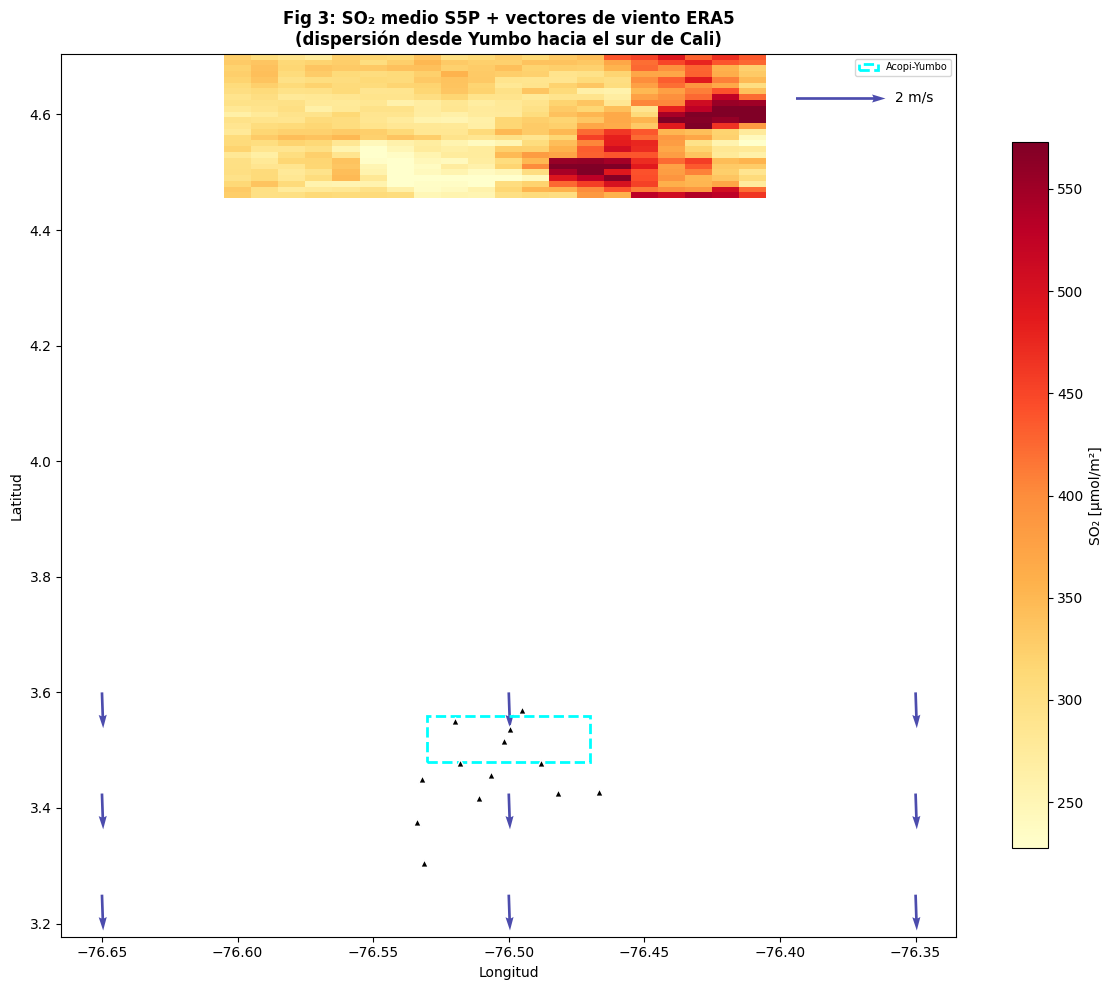

PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/integral/03_so2_viento_mapa.png')

In [14]:
print("[Fig 3] Mapa bivariado SO2 + viento...")

so2_cali = so2_mean[CALI_LAT_SLICE, CALI_LON_SLICE]

u_mean = np.nanmean(list(wind_u.values())) if wind_u else 0
v_mean = np.nanmean(list(wind_v.values())) if wind_v else 0

er5_lon = np.linspace(-76.65, -76.35, 5)
er5_lat = np.linspace(3.25,   3.60,   5)
er5_lon_grid, er5_lat_grid = np.meshgrid(er5_lon, er5_lat)

fig, ax = plt.subplots(figsize=(12, 10))

vmin = np.nanpercentile(so2_cali, 2)
vmax = np.nanpercentile(so2_cali, 98)
im = ax.pcolormesh(
    lon_mesh, lat_mesh, so2_cali,
    cmap="YlOrRd", shading="auto", vmin=vmin, vmax=vmax
)

step = 2
q = ax.quiver(
    er5_lon_grid[::step, ::step], er5_lat_grid[::step, ::step],
    np.full_like(er5_lon_grid[::step, ::step], u_mean * 1.5),
    np.full_like(er5_lat_grid[::step, ::step], v_mean * 1.5),
    scale=20, width=0.003, color="darkblue", alpha=0.7
)

for name, (lon, lat) in DAGMA_STATIONS.items():
    ax.scatter(lon, lat, c="black", s=30, marker="^", edgecolors="white", zorder=10)

ax.quiverkey(q, 0.92, 0.95, 2, "2 m/s", labelpos="E", color="darkblue")
ax.add_patch(plt.Rectangle(
    (-76.53, 3.48), 0.06, 0.08,
    lw=2, edgecolor="cyan", facecolor="none", ls="--", label="Acopi-Yumbo"
))
plt.colorbar(im, ax=ax, label="SO₂ [µmol/m²]", shrink=0.8)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(fontsize=7)
ax.set_title(
    "Fig 3: SO₂ medio S5P + vectores de viento ERA5\n"
    "(dispersión desde Yumbo hacia el sur de Cali)",
    fontweight="bold"
)
fig.tight_layout()
save("03_so2_viento_mapa")

---
## Fig 4 · Hexbin NDVI (Sentinel-2) vs NO₂ (Sentinel-5P)

[Fig 4] Hexbin NDVI vs NO₂...


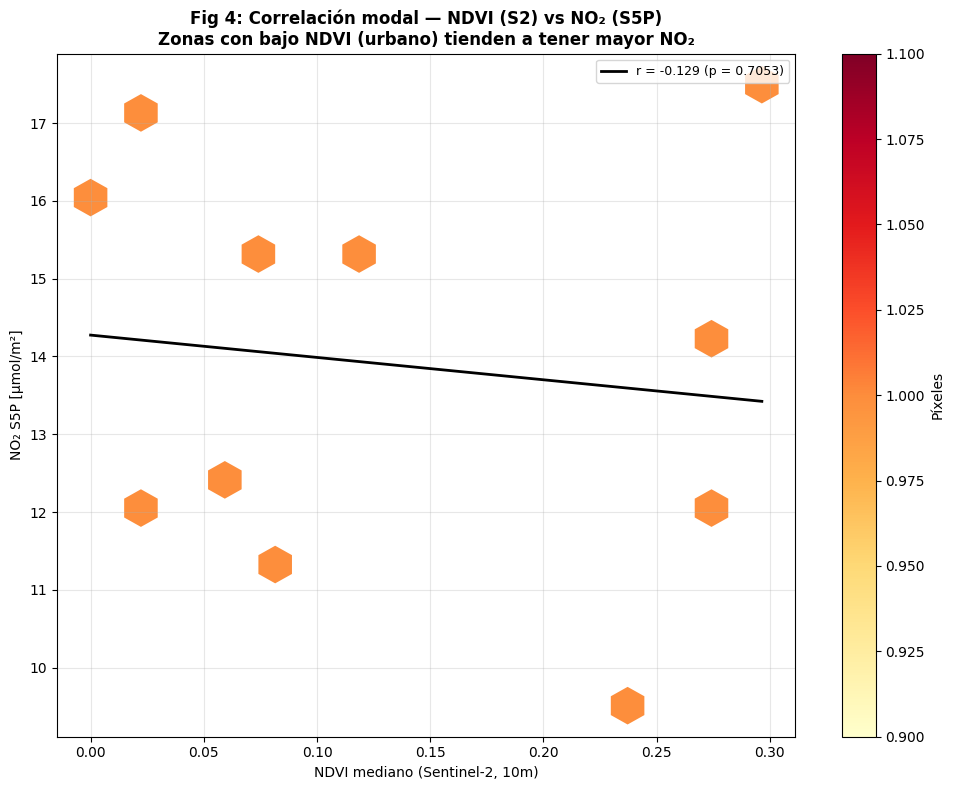

In [15]:
print("[Fig 4] Hexbin NDVI vs NO₂...")

ndvi_vals = []; no2_vals = []

for dt_str, ndvi_val in s2_no2_by_date.items():
    matches = [
        (abs((pd.Timestamp(dt_str) - d).days), d)
        for d in s5p_df["date"]
        if abs((pd.Timestamp(dt_str) - d).days) <= 3
    ]
    if matches:
        nearest  = min(matches, key=lambda x: x[0])
        s5p_row  = s5p_df[s5p_df["date"] == nearest[1]]
        if len(s5p_row) > 0 and not np.isnan(s5p_row["no2_mean"].values[0]):
            ndvi_vals.append(ndvi_val)
            no2_vals.append(s5p_row["no2_mean"].values[0])

if len(ndvi_vals) > 5:
    fig, ax = plt.subplots(figsize=(10, 8))
    hb = ax.hexbin(ndvi_vals, no2_vals, gridsize=20, cmap="YlOrRd", mincnt=1, edgecolors="none")

    sl, ic, r, p, _ = stats.linregress(ndvi_vals, no2_vals)
    xf = np.linspace(min(ndvi_vals), max(ndvi_vals), 100)
    ax.plot(xf, sl * xf + ic, "k-", lw=2, label=f"r = {r:.3f} (p = {p:.4f})")

    ax.set_xlabel("NDVI mediano (Sentinel-2, 10m)")
    ax.set_ylabel("NO₂ S5P [µmol/m²]")
    ax.legend(fontsize=9)
    plt.colorbar(hb, ax=ax, label="Píxeles")
    ax.set_title(
        "Fig 4: Correlación modal — NDVI (S2) vs NO₂ (S5P)\n"
        "Zonas con bajo NDVI (urbano) tienden a tener mayor NO₂",
        fontweight="bold"
    )
    ax.grid(alpha=0.3)
    fig.tight_layout()
    save("04_ndvi_vs_no2_hexbin")
else:
    print("  ⚠ Datos insuficientes para Fig 4")

---
## Fig 5 · Semivariograma experimental NO₂ — grilla S5P

[Fig 5] Semivariograma NO₂ grilla S5P...


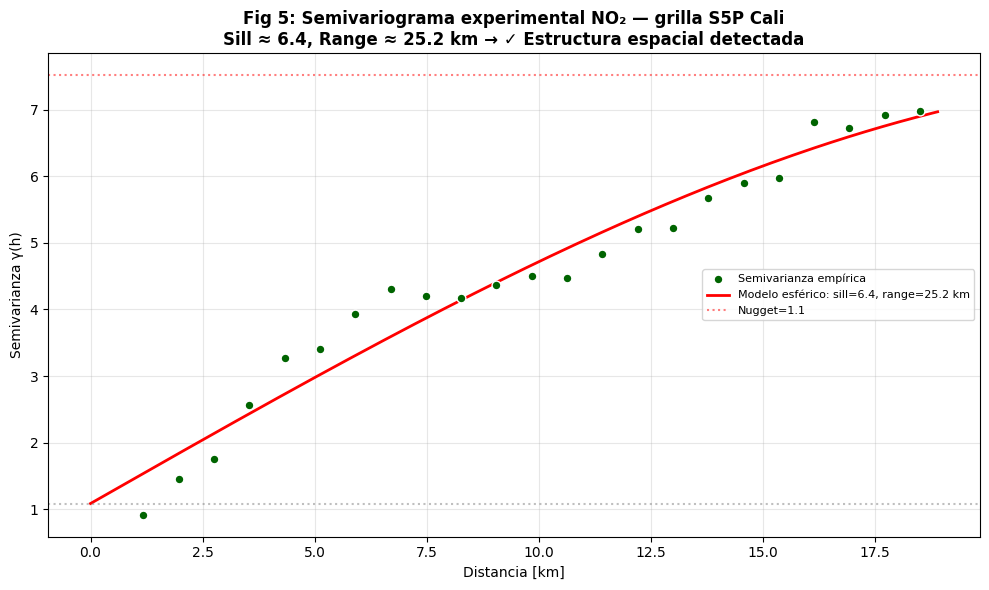

In [16]:
print("[Fig 5] Semivariograma NO₂ grilla S5P...")

from scipy.optimize import curve_fit

cali_no2 = no2_mean[CALI_LAT_SLICE, CALI_LON_SLICE]
mask = ~np.isnan(cali_no2)

if mask.sum() > 100:
    rows, cols = np.where(mask)
    idx        = np.random.choice(len(rows), min(300, len(rows)), replace=False)
    sample_lon = lon_mesh[rows[idx], cols[idx]]
    sample_lat = lat_mesh[rows[idx], cols[idx]]
    sample_val = cali_no2[rows[idx], cols[idx]]
    coords     = np.column_stack([sample_lon, sample_lat])

    dists = squareform(pdist(coords)) * 111          # km
    diffs = squareform(pdist(sample_val.reshape(-1, 1)) ** 2)

    max_d = np.percentile(dists[dists > 0], 80)
    bins  = np.linspace(0, max_d, 25)
    gamma = []; bin_centers = []

    for i in range(len(bins) - 1):
        m = (dists > bins[i]) & (dists <= bins[i + 1])
        if m.sum() >= 5:
            gamma.append(diffs[m].mean() / 2)
            bin_centers.append((bins[i] + bins[i + 1]) / 2)

    bc, gm = np.array(bin_centers), np.array(gamma)

    def spherical(h, sill, rng, nugget):
        ratio = h / (rng + 1e-10)
        return np.where(
            h <= rng,
            nugget + sill * (1.5 * ratio - 0.5 * ratio**3),
            nugget + sill
        )

    try:
        popt, _ = curve_fit(
            spherical, bc, gm,
            p0=[max(gm), max(bc) * 0.5, gm[0]],
            bounds=([0, 0, 0], [max(gm) * 2, max(bc) * 2, max(gm)])
        )
    except:
        popt = [max(gm), max(bc) * 0.5, gm[0]]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(bc, gm, s=40, c="darkgreen", edgecolors="white", zorder=5, label="Semivarianza empírica")

    h_fit = np.linspace(0, max_d, 200)
    ax.plot(
        h_fit, spherical(h_fit, *popt), "r-", lw=2,
        label=f"Modelo esférico: sill={popt[0]:.1f}, range={popt[1]:.1f} km"
    )
    ax.axhline(popt[0] + popt[2], color="red",  ls=":", alpha=0.5, label=f"Nugget={popt[2]:.1f}")
    ax.axhline(popt[2],           color="gray", ls=":", alpha=0.5)

    ax.set_xlabel("Distancia [km]")
    ax.set_ylabel("Semivarianza γ(h)")
    ax.set_title(
        f"Fig 5: Semivariograma experimental NO₂ — grilla S5P Cali\n"
        f"Sill ≈ {popt[0]:.1f}, Range ≈ {popt[1]:.1f} km → "
        f"{'✓ Estructura espacial detectada' if popt[0] > 2 else '⚠ Débil autocorrelación'}",
        fontweight="bold"
    )
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    save("05_semivariograma_no2_s5p")
else:
    print("  ⚠ Píxeles válidos insuficientes para Fig 5")

---
## Resumen final

In [17]:
ng = len(list(OUT_DIR.glob("*.png")))
print("=" * 70)
print(f"✅ EDA Panel Integral → {OUT_DIR}")
print(f"   {ng}/5 gráficas generadas")
print(f"   Arquitectura: Dask + xarray para tensores 5D")
print(f"   Cumple requerimientos Situación 1 del auditor")
print("=" * 70)

✅ EDA Panel Integral → /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/integral
   5/5 gráficas generadas
   Arquitectura: Dask + xarray para tensores 5D
   Cumple requerimientos Situación 1 del auditor
